# Project Business Statistics: E-news Express


> **Summary:** A/B test of a redesigned landing page (n = 100). The new page increased time on page (+1.7 min, p < 0.001) and conversion (66% vs 42%, p = 0.008). Language had no significant effect. Recommendation: roll out the new page.

## Define Problem Statement and Objectives
Problem Statement:
E-news Express, an online news portal, aims to expand its business by acquiring new subscribers. However, there has been a decline in new monthly subscribers compared to the past year. The company suspects that the current webpage design may not effectively engage users to make a decision to subscribe. To address this, the company has developed a new landing page with a redesigned outline and more relevant content. The goal is to determine if the new landing page is more effective in gathering new subscribers compared to the existing landing page.

Objectives:

Evaluate whether users spend more time on the new landing page compared to the existing landing page.
Determine if the conversion rate for the new landing page is greater than for the existing landing page.
Investigate if the conversion status depends on the preferred language of the user.
Assess if the time spent on the new landing page varies across different language preferences of users.


## Import all the necessary libraries

In [1]:
# Colab only: pin library versions
# !pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scipy==1.11.4 -q


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

## Reading the Data into a DataFrame

In [2]:
# Data is in data/abtest.csv (no Google Drive mount needed)


In [3]:
import pandas as pd
import numpy as np

file_path = "data/abtest.csv"

# Read the data into a DataFrame
df = pd.read_csv(file_path)

print(df.head())


   user_id      group landing_page  time_spent_on_the_page converted  \
0   546592    control          old                    3.48        no   
1   546468  treatment          new                    7.13       yes   
2   546462  treatment          new                    4.40        no   
3   546567    control          old                    3.02        no   
4   546459  treatment          new                    4.75       yes   

  language_preferred  
0            Spanish  
1            English  
2            Spanish  
3             French  
4            Spanish  


## Explore the dataset and extract insights using Exploratory Data Analysis

- Data Overview
  - Viewing the first and last few rows of the dataset
  - Checking the shape of the dataset
  - Getting the statistical summary for the variables
- Check for missing values
- Check for duplicates

In [4]:
# Viewing the first few rows of the dataset
print("First few rows:")
print(df.head())

# Viewing the last few rows of the dataset
print("\nLast few rows:")
print(df.tail())

# Checking the shape of the dataset
print("\nShape of the dataset:", df.shape)

# Getting the statistical summary for the variables
print("\nStatistical summary:")
print(df.describe())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check for duplicates
print("\nDuplicates:", df.duplicated().sum())


First few rows:
   user_id      group landing_page  time_spent_on_the_page converted  \
0   546592    control          old                    3.48        no   
1   546468  treatment          new                    7.13       yes   
2   546462  treatment          new                    4.40        no   
3   546567    control          old                    3.02        no   
4   546459  treatment          new                    4.75       yes   

  language_preferred  
0            Spanish  
1            English  
2            Spanish  
3             French  
4            Spanish  

Last few rows:
    user_id      group landing_page  time_spent_on_the_page converted  \
95   546446  treatment          new                    5.15        no   
96   546544    control          old                    6.52       yes   
97   546472  treatment          new                    7.07       yes   
98   546481  treatment          new                    6.20       yes   
99   546483  treatment          

### Univariate Analysis

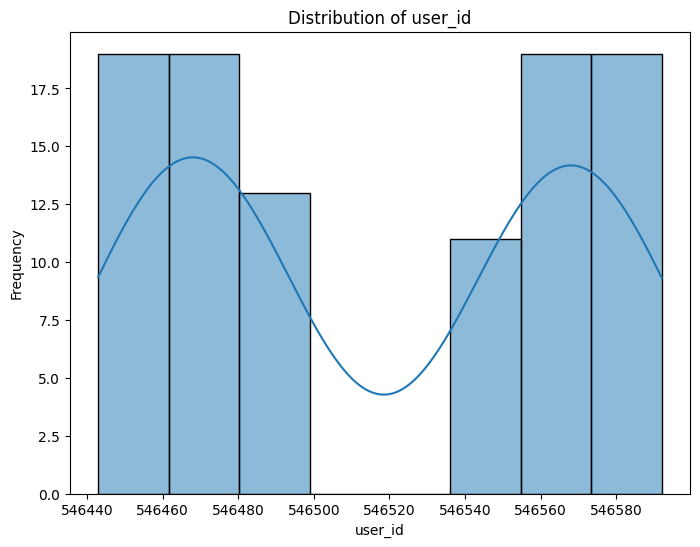

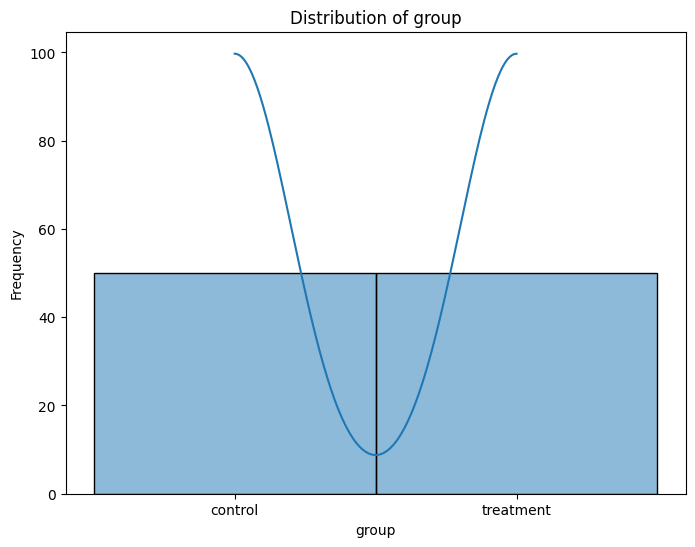

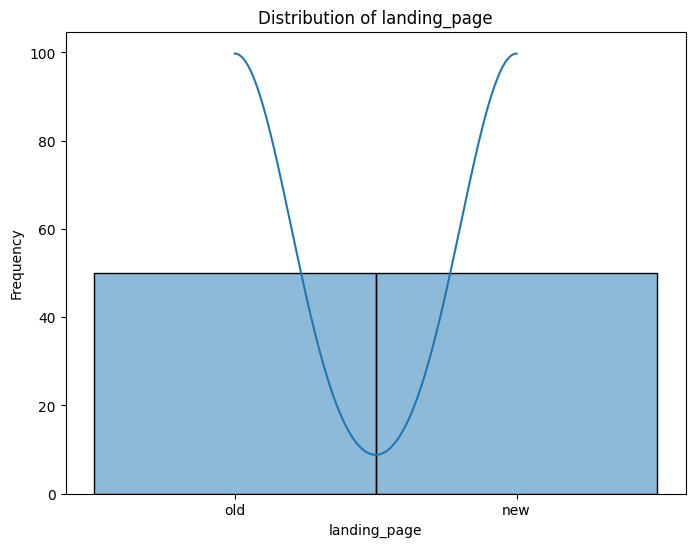

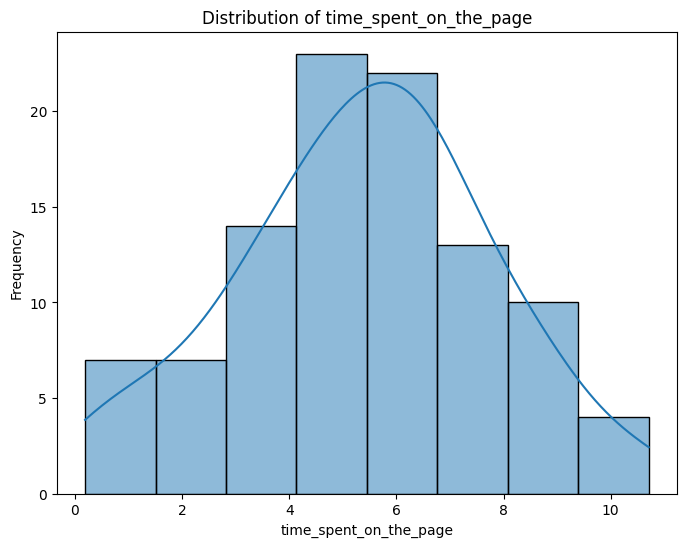

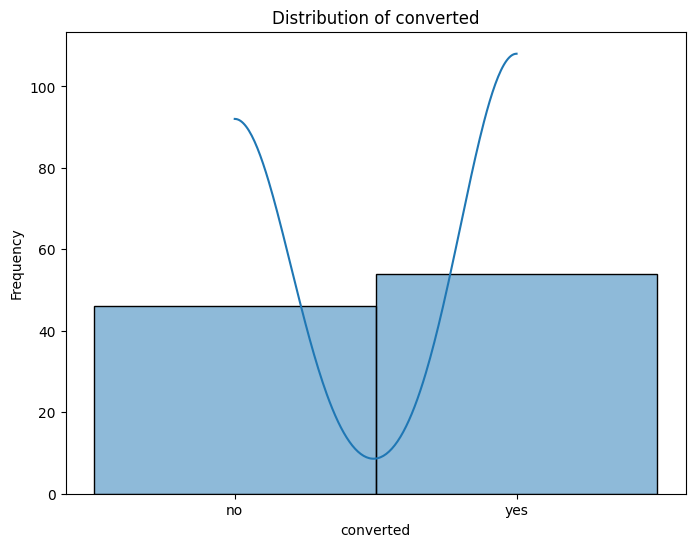

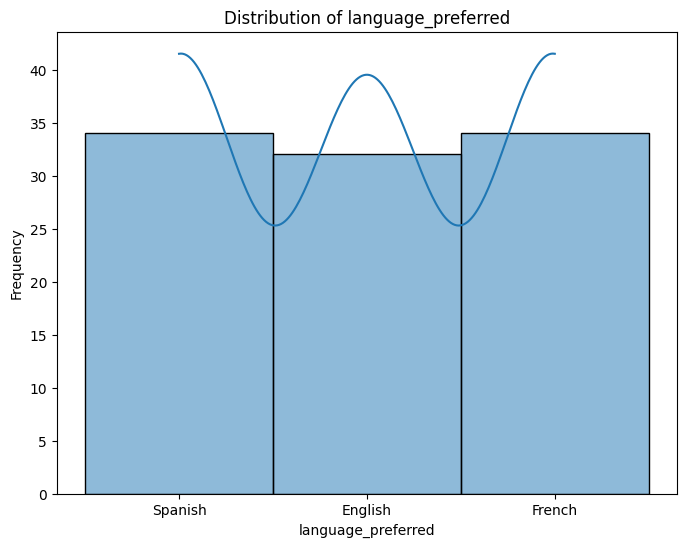

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a function for univariate analysis
def univariate_analysis(data, column):
    plt.figure(figsize=(8, 6))
    if data[column].dtype == 'object':  # Categorical variable
        sns.countplot(data[column])
        plt.title(f'Distribution of {column}')
        plt.xlabel('count')
        plt.ylabel(column)
        plt.xticks(rotation=45)
    else:  # Numerical variable
        sns.histplot(data[column], kde=True)
        plt.title(f'Distribution of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
    plt.show()

# Perform univariate analysis for each column in the dataset
for column in df.columns:
    univariate_analysis(df, column)


### Bivariate Analysis

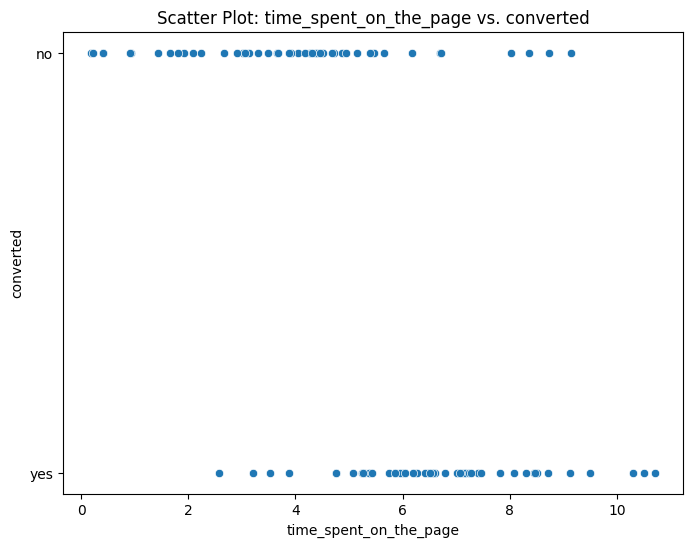

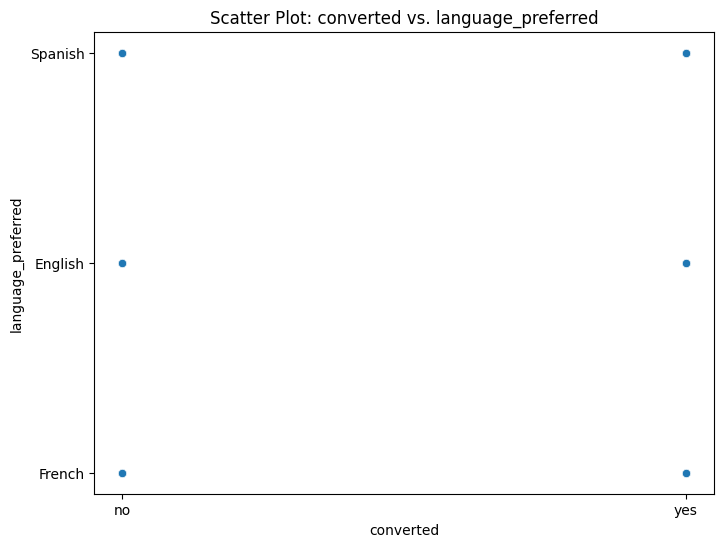

In [6]:
# Define function for bivariate analysis
def bivariate_analysis(data, x, y):
    plt.figure(figsize=(8, 6))
    if data[x].dtype == 'object' and data[y].dtype == 'object':  # Categorical vs. Categorical
        contingency_table = pd.crosstab(data[x], data[y])
        sns.heatmap(contingency_table, annot=True, cmap='YlGnBu', fmt='d')
        plt.title(f'Contingency Table: {x} vs. {y}')
        plt.xlabel(y)
        plt.ylabel(x)
    elif data[x].dtype != 'object' and data[y].dtype != 'object':  # Numerical vs. Numerical
        sns.scatterplot(data=data, x=x, y=y)
        plt.title(f'Scatter Plot: {x} vs. {y}')
        plt.xlabel(x)
        plt.ylabel(y)
    else:  # Numerical vs. Categorical
        sns.boxplot(data=data, x=y, y=x)
        plt.title(f'Box Plot: {x} vs. {y}')
        plt.xlabel(y)
        plt.ylabel(x)
    plt.show()

# Perform bivariate analysis for selected pairs of variables
bivariate_analysis(df, 'time_spent_on_the_page', 'converted')
bivariate_analysis(df, 'converted', 'language_preferred')
# Add more pairs of variables as needed


## 1. Do the users spend more time on the new landing page than the existing landing page?

### Perform Visual Analysis

### Step 1: Define the null and alternate hypotheses

Null Hypothesis (H0): Mean time on the new page is equal to or less than mean time on the existing page.

### Step 2: Select Appropriate test

We'll use a one-sided two-sample Welch t-test (unequal variances), because the question asks whether the new page has *more* time spent.

### Step 3: Decide the significance level

We'll use a significance level of 0.05

### Step 4: Collect and prepare data

### Step 5: Calculate the p-value

In [7]:
from scipy.stats import ttest_ind

# Separate data for control (existing landing page) and treatment (new landing page) groups
control_group = df[df['group'] == 'control']['time_spent_on_the_page']
treatment_group = df[df['group'] == 'treatment']['time_spent_on_the_page']

# One-sided Welch t-test: is time on the NEW page greater?
t_statistic, p_value = ttest_ind(treatment_group, control_group, equal_var=False, alternative='greater')

# Set significance level
alpha = 0.05

# Print results
if p_value < alpha:
    print("The p-value is {:.4f}, which is less than the significance level of {:.2f}.".format(p_value, alpha))
    print("We reject the null hypothesis.")
    print("There is a significant difference in the mean time spent on the page between the control and treatment groups.")
else:
    print("The p-value is {:.4f}, which is greater than the significance level of {:.2f}.".format(p_value, alpha))
    print("We fail to reject the null hypothesis.")
    print("There is no significant difference in the mean time spent on the page between the control and treatment groups.")


The p-value is 0.0001, which is less than the significance level of 0.05.
We reject the null hypothesis.
There is a significant difference in the mean time spent on the page between the control and treatment groups.


### Step 6: Compare the p-value with $\alpha$

The P-value is less than the significance level 0.05

### Step 7:  Draw inference

The p-value is below 0.05, so we reject H0. Users spend significantly more time on the new page (mean 6.22 min vs 4.53 min, about +1.7 min).

This is a randomised A/B test (users assigned to control/treatment), so the difference can be attributed to the page design.

**A similar approach can be followed to answer the other questions.**

## 2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

Null Hypothesis (H0): The conversion rate for the new landing page is equal to or less than the conversion rate for the old landing page.

Alternative Hypothesis (H1): The conversion rate for the new landing page is greater than the conversion rate for the old landing page.

we will use a one-tailed Z-test for proportions to compare the conversion rates.



We'll use a significance level of 0.05

In [8]:
from statsmodels.stats.proportion import proportions_ztest

# Convert "yes" to 1 and "no" to 0 in the "converted" column
df['converted'] = df['converted'].map({"no": 0, "yes": 1})

# Counting the number of conversions and total users for the old and new landing pages
old_converted = df[df['landing_page'] == 'old']['converted'].sum()
old_total = len(df[df['landing_page'] == 'old'])
new_converted = df[df['landing_page'] == 'new']['converted'].sum()
new_total = len(df[df['landing_page'] == 'new'])

# Perform one-tailed Z-test for proportions
count = np.array([new_converted, old_converted])
nobs = np.array([new_total, old_total])
stat, p_value = proportions_ztest(count, nobs, alternative='larger')

# Set significance level
alpha = 0.05

# Print results
if p_value < alpha:
    print("The p-value is {:.4f}, which is less than the significance level of {:.2f}.".format(p_value, alpha))
    print("We reject the null hypothesis.")
    print("The conversion rate for the new landing page is greater than the conversion rate for the old landing page.")
else:
    print("The p-value is {:.4f}, which is greater than the significance level of {:.2f}.".format(p_value, alpha))
    print("We fail to reject the null hypothesis.")
    print("There is no sufficient evidence to conclude that the conversion rate for the new landing page is greater than the conversion rate for the old landing page.")


The p-value is 0.0080, which is less than the significance level of 0.05.
We reject the null hypothesis.
The conversion rate for the new landing page is greater than the conversion rate for the old landing page.


The p-value (0.008) is below 0.05, so we reject H0. The new page converts significantly better: **66% vs 42%** (+24 percentage points).

## 3. Is the conversion and preferred language are independent or related?

Null Hypothesis (H0): Conversion status and preferred language are independent.

Alternative Hypothesis (H1): Conversion status and preferred language are not independent (i.e., they are related).

the chi-square test of independence will be used to determine whether there is a significant relation between conversion status and preferred language.



We'll use a significance level of 0.05

In [9]:
from scipy.stats import chi2_contingency
# Convert 0 back to 'no' and 1 back to 'yes'
df['converted'] = df['converted'].map({0: 'no', 1: 'yes'})

# Create contingency table
contingency_table = pd.crosstab(df['converted'], df['language_preferred'])

# Perform chi-square test of independence
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Set significance level
alpha = 0.05

# Print results
if p_value < alpha:
    print("The p-value is {:.4f}, which is less than the significance level of {:.2f}.".format(p_value, alpha))
    print("We reject the null hypothesis.")
    print("There is a significant association between conversion status and preferred language.")
else:
    print("The p-value is {:.4f}, which is greater than the significance level of {:.2f}.".format(p_value, alpha))
    print("We fail to reject the null hypothesis.")
    print("There is no sufficient evidence to conclude that conversion status and preferred language are related.")


The p-value is 0.2130, which is greater than the significance level of 0.05.
We fail to reject the null hypothesis.
There is no sufficient evidence to conclude that conversion status and preferred language are related.


Based on the result of the chi-square test of independence, we fail to reject the null hypothesis. This means that there is no sufficient evidence to conclude that conversion status and preferred language are related. In other words, the analysis suggests that there is no significant association between conversion status and preferred language chosen by the user.

This finding implies that the preferred language chosen by users does not significantly influence their likelihood of conversion. Therefore, the choice of language may not be a significant factor in determining conversion status.



## 4. Is the time spent on the new page same for the different language users?

Null Hypothesis (H0): The mean time spent on the new page is the same for users of different preferred languages.

Alternative Hypothesis (H1): At least one group (language) has a different mean time spent on the new page compared to the others.

hWe'll use a significance level of 0.05.

the ANOVA test will compare the means of the time spent on the new page across different language groups.

In [10]:
from scipy.stats import f_oneway

# Extract time spent on the NEW page only, for each language group
new_page = df[df['landing_page'] == 'new']
time_spent_by_language = [g['time_spent_on_the_page'] for _, g in new_page.groupby('language_preferred')]
print(new_page.groupby('language_preferred')['time_spent_on_the_page'].mean().round(2))

# Perform ANOVA test
statistic, p_value = f_oneway(*time_spent_by_language)

# Set significance level
alpha = 0.05

# Print results
if p_value < alpha:
    print("The p-value is {:.4f}, which is less than the significance level of {:.2f}.".format(p_value, alpha))
    print("We reject the null hypothesis.")
    print("There are statistically significant differences in the mean time spent on the new page among different language groups.")
else:
    print("The p-value is {:.4f}, which is greater than the significance level of {:.2f}.".format(p_value, alpha))
    print("We fail to reject the null hypothesis.")
    print("There is no sufficient evidence to conclude that the mean time spent on the new page differs among different language groups.")


language_preferred
English    6.66
French     6.20
Spanish    5.84
Name: time_spent_on_the_page, dtype: float64
The p-value is 0.4320, which is greater than the significance level of 0.05.
We fail to reject the null hypothesis.
There is no sufficient evidence to conclude that the mean time spent on the new page differs among different language groups.


Based on the result of the ANOVA test, we fail to reject the null hypothesis, indicating that there is no sufficient evidence to conclude that the mean time spent on the new page differs among different language groups. In other words, the analysis suggests that the preferred language chosen by users does not significantly affect the amount of time they spend on the new page.

This finding implies that, on average, users across different language groups spend a similar amount of time on the new page. Therefore, language preference alone may not be a significant factor influencing user engagement with the new page.

## Conclusion and Business Recommendations

**Results**

| Question | Test | p-value | Result |
|---|---|---|---|
| More time on new page? | Welch t-test (one-sided) | 0.0001 | Yes: 6.22 vs 4.53 min |
| Higher conversion on new page? | Two-proportion z-test (one-sided) | 0.008 | Yes: 66% vs 42% |
| Conversion depends on language? | Chi-square | 0.21 | No evidence |
| Time on new page differs by language? | One-way ANOVA (new page only) | 0.43 | No evidence |

**Recommendations**

1. **Roll out the new landing page.** It increases both engagement and conversion, and the effect is large.
2. **No language-specific redesign is needed.** The new page works similarly for English, French and Spanish users.
3. **Monitor after launch.** Track conversion weekly to confirm the uplift holds beyond the 100-user test.

**Limitations:** small sample (50 per group); time on page is a proxy for engagement; a single test window may include novelty effects.